# Laboratorio 03: Regresión Polinómica

## Predicción de la Temperatura Crítica de Superconductores

In [1]:
# 1. Importaciones y Google Drive

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## 2. Carga del Dataset

In [2]:
# Ruta del dataset
ruta = '/content/drive/MyDrive/Inteligencia Artificial/Laboratorio 03/train.csv'

# Cargar dataset
df = pd.read_csv(ruta)

print("Dimensiones del dataset:", df.shape)
print("Cantidad de ejemplos (m):", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

df.head()

Dimensiones del dataset: (21263, 82)
Cantidad de ejemplos (m): 21263
Cantidad de columnas: 82


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


## 3. Exploración y análisis del Dataset

In [3]:
# Información general del dataset

print("Tipos de datos:")
print(df.dtypes.value_counts())

print("\nValores nulos totales:")
print(df.isnull().sum().sum())

print("\nFilas duplicadas:")
print(df.duplicated().sum())

print("\nEstadísticas de critical_temp:")
print(df['critical_temp'].describe())

Tipos de datos:
float64    79
int64       3
Name: count, dtype: int64

Valores nulos totales:
0

Filas duplicadas:
66

Estadísticas de critical_temp:
count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64


In [4]:
# Correlación de cada característica con critical_temp
correlaciones = df.corr(numeric_only=True)['critical_temp'].drop('critical_temp')

# Ordenar según la correlación absoluta
correlaciones_ordenadas = correlaciones.reindex(
    correlaciones.abs().sort_values(ascending=False).index
)

print("10 características con mayor relación con critical_temp:\n")
print(correlaciones_ordenadas.head(10))

10 características con mayor relación con critical_temp:

wtd_std_ThermalConductivity    0.721271
range_ThermalConductivity      0.687654
range_atomic_radius            0.653759
std_ThermalConductivity        0.653632
wtd_mean_Valence              -0.632401
wtd_entropy_atomic_mass        0.626930
wtd_gmean_Valence             -0.615653
wtd_entropy_atomic_radius      0.603494
number_of_elements             0.601069
range_fie                      0.600790
Name: critical_temp, dtype: float64


Características seleccionadas:
['wtd_std_ThermalConductivity', 'range_ThermalConductivity']


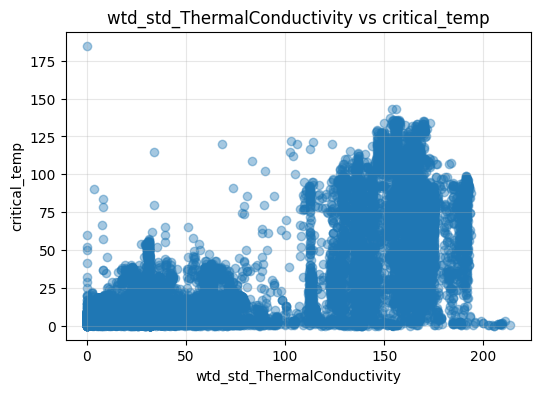

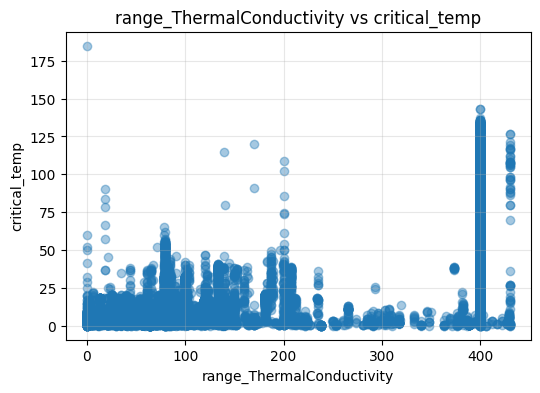

In [5]:
# Seleccionar las 2 características con mayor correlación
mejores_2 = correlaciones_ordenadas.head(2).index.tolist()

print("Características seleccionadas:")
print(mejores_2)

# Gráficas
for columna in mejores_2:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[columna], df['critical_temp'], alpha=0.4)
    plt.xlabel(columna)
    plt.ylabel('critical_temp')
    plt.title(f'{columna} vs critical_temp')
    plt.grid(alpha=0.3)
    plt.show()

## 4. Preprocesamiento

In [27]:
# Seleccionar las 20 características con mayor correlación absoluta
caracteristicas = (
    correlaciones.abs()
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

# Para la regresión polinómica utilizaremos las 2 más relacionadas
caracteristicas_poly = caracteristicas[:2]

# Datos para regresión lineal multivariable
X = df[caracteristicas].values.astype(float)

# Datos para regresión polinómica
X_poly = df[caracteristicas_poly].values.astype(float)

# Variable objetivo
y = df['critical_temp'].values.astype(float)

m = len(y)

print("Características seleccionadas para regresión multivariable:")
for i, columna in enumerate(caracteristicas, 1):
    print(f"{i}. {columna}")

print("\nCaracterísticas para regresión polinómica:")
print(caracteristicas_poly)

# División aleatoria 80% entrenamiento - 20% prueba
np.random.seed(42)

indices = np.random.permutation(m)
limite = int(0.8 * m)

indices_train = indices[:limite]
indices_test = indices[limite:]

X_train = X[indices_train]
X_test = X[indices_test]

X_poly_train = X_poly[indices_train]
X_poly_test = X_poly[indices_test]

y_train = y[indices_train]
y_test = y[indices_test]

print("\n--- División del Dataset ---")
print("Datos de entrenamiento:", len(y_train))
print("Datos de prueba:", len(y_test))
print("Total:", len(y_train) + len(y_test))

Características seleccionadas para regresión multivariable:
1. wtd_std_ThermalConductivity
2. range_ThermalConductivity
3. range_atomic_radius
4. std_ThermalConductivity
5. wtd_mean_Valence
6. wtd_entropy_atomic_mass
7. wtd_gmean_Valence
8. wtd_entropy_atomic_radius
9. number_of_elements
10. range_fie
11. mean_Valence
12. wtd_std_atomic_radius
13. entropy_Valence
14. wtd_entropy_Valence
15. wtd_std_fie
16. gmean_Valence
17. entropy_fie
18. wtd_entropy_FusionHeat
19. std_atomic_radius
20. entropy_atomic_radius

Características para regresión polinómica:
['wtd_std_ThermalConductivity', 'range_ThermalConductivity']

--- División del Dataset ---
Datos de entrenamiento: 16957
Datos de prueba: 4240
Total: 21197


5. Normalización

In [28]:
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división por cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [29]:
# Normalizar datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Normalizar datos de prueba usando los mismos mu y sigma
X_test_norm = (X_test - mu) / sigma

In [30]:
# Agregar columna de unos para theta_0
X_train_norm = np.concatenate(
    [np.ones((X_train_norm.shape[0], 1)), X_train_norm],
    axis=1
)

X_test_norm = np.concatenate(
    [np.ones((X_test_norm.shape[0], 1)), X_test_norm],
    axis=1
)

print("Dimensión X_train normalizado:", X_train_norm.shape)
print("Dimensión X_test normalizado:", X_test_norm.shape)

Dimensión X_train normalizado: (16957, 21)
Dimensión X_test normalizado: (4240, 21)


6. Funciones de costo

In [31]:
def computeCostMulti(X, y, theta):
    m = len(y)

    predicciones = np.dot(X, theta)
    errores = predicciones - y

    J = (1 / (2 * m)) * np.sum(errores ** 2)

    return J

7. Descenso por el Gradiente

In [32]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = len(y)

    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        predicciones = np.dot(X, theta)
        errores = predicciones - y

        theta = theta - (alpha / m) * np.dot(X.T, errores)

        J_history.append(
            computeCostMulti(X, y, theta)
        )

    return theta, J_history

8. Regresión Lineal Multivariable - Entrenamiento

In [33]:
# Parámetros de entrenamiento
alpha = 0.01
num_iters = 1500

# Inicializar theta en cero
theta = np.zeros(X_train_norm.shape[1])

# Entrenar modelo
theta_lineal, J_history_lineal = gradientDescentMulti(
    X_train_norm,
    y_train,
    theta,
    alpha,
    num_iters
)

print("Entrenamiento completado.")
print("Costo final:", J_history_lineal[-1])

print("\nValores de theta:")
print(theta_lineal)

Entrenamiento completado.
Costo final: 235.75741135062538

Valores de theta:
[34.56965001 14.92273322  2.14800325  9.39866925 -2.45771339 -3.68220871
  8.60738119  1.54294384 -2.10114021  5.64909597  4.31798911 -4.54517672
 -1.36265454 -0.34077999  0.24866912 -6.5287752   1.58406967 -4.56312986
  1.91879943 -2.31564974 -4.96657287]


9. Gráfica del costo - Regresión Lineal Multivariable

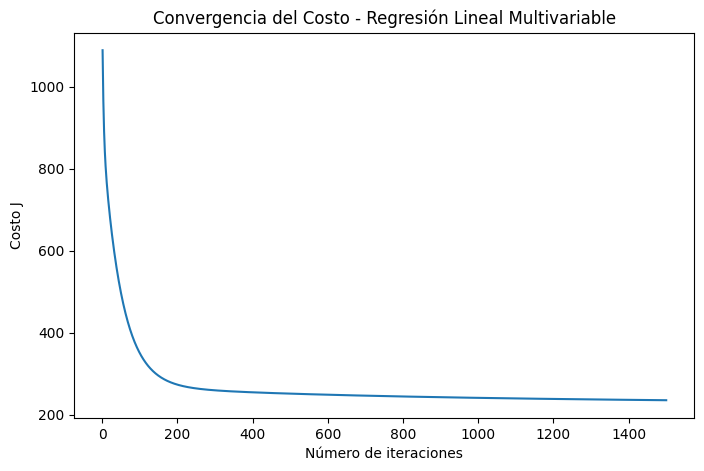

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_iters + 1),
    J_history_lineal
)

plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Costo - Regresión Lineal Multivariable')

plt.show()

## 10. Preparación de la Regresión Polinómica

In [35]:
def crearCaracteristicasPolinomicas(X):
    x1 = X[:, 0]
    x2 = X[:, 1]

    X_poly = np.column_stack([
        x1,
        x2,
        x1**2,
        x1 * x2,
        x2**2
    ])

    return X_poly

In [36]:
# Crear características polinómicas
X_poly_train_g2 = crearCaracteristicasPolinomicas(X_poly_train)
X_poly_test_g2 = crearCaracteristicasPolinomicas(X_poly_test)

print("Características originales:")
print(caracteristicas_poly)

print("\nTérminos polinómicos:")
print("x1, x2, x1², x1*x2, x2²")

print("\nDimensión entrenamiento:", X_poly_train_g2.shape)
print("Dimensión prueba:", X_poly_test_g2.shape)

Características originales:
['wtd_std_ThermalConductivity', 'range_ThermalConductivity']

Términos polinómicos:
x1, x2, x1², x1*x2, x2²

Dimensión entrenamiento: (16957, 5)
Dimensión prueba: (4240, 5)


# 11. Normalización de datos polinómicos

In [37]:
# Normalizar características polinómicas de entrenamiento
X_poly_train_norm, mu_poly, sigma_poly = featureNormalize(X_poly_train_g2)

# Normalizar datos de prueba con los mismos valores
X_poly_test_norm = (X_poly_test_g2 - mu_poly) / sigma_poly

In [38]:
# Agregar columna de unos para theta_0
X_poly_train_norm = np.concatenate(
    [np.ones((X_poly_train_norm.shape[0], 1)), X_poly_train_norm],
    axis=1
)

X_poly_test_norm = np.concatenate(
    [np.ones((X_poly_test_norm.shape[0], 1)), X_poly_test_norm],
    axis=1
)

print("Dimensión X_poly_train normalizado:", X_poly_train_norm.shape)
print("Dimensión X_poly_test normalizado:", X_poly_test_norm.shape)

Dimensión X_poly_train normalizado: (16957, 6)
Dimensión X_poly_test normalizado: (4240, 6)


12. Entrenamiento de la Regresión Polinómica,

In [39]:
# Parámetros de entrenamiento
alpha_poly = 0.01
num_iters_poly = 1500

# Inicializar theta
theta_poly_inicial = np.zeros(X_poly_train_norm.shape[1])

# Entrenar modelo polinómico
theta_poly, J_history_poly = gradientDescentMulti(
    X_poly_train_norm,
    y_train,
    theta_poly_inicial,
    alpha_poly,
    num_iters_poly
)

print("Entrenamiento polinómico completado.")
print("Costo final:", J_history_poly[-1])

print("\nValores de theta:")
print(theta_poly)

Entrenamiento polinómico completado.
Costo final: 268.4097596274208

Valores de theta:
[34.56965001  4.25543151 -1.90914336 11.95708854  8.5632791   2.22801128]


13. Gráfica del costo — Regresión Polinómica

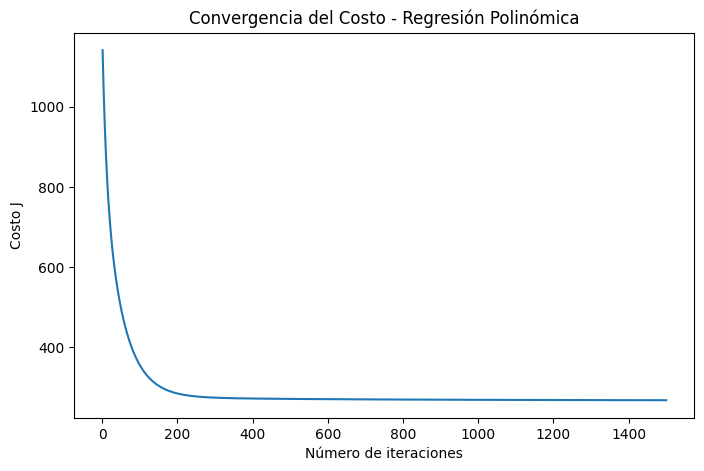

In [40]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_iters_poly + 1),
    J_history_poly
)

plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del Costo - Regresión Polinómica')

plt.show()

## 14. Ecuación de la Normal

In [41]:
# Calcular theta mediante la Ecuación de la Normal
theta_normal = np.linalg.pinv(
    X_train_norm.T @ X_train_norm
) @ X_train_norm.T @ y_train

# Calcular costo
costo_normal = computeCostMulti(
    X_train_norm,
    y_train,
    theta_normal
)

print("Theta calculado por la Ecuación de la Normal:")
print(theta_normal)

print("\nCosto del modelo:", costo_normal)

Theta calculado por la Ecuación de la Normal:
[ 34.56965981  21.38006474   5.3647486   38.0116015  -13.55939734
 -36.09455094  10.44035143  37.25886666   0.37823599  -3.56995496
  14.76777138 -19.41051951   3.64687825 -25.29087321  -6.20143579
 -14.59715985  13.76840426  67.08101541   5.03990026 -31.81973005
 -51.43552241]

Costo del modelo: 216.94183598092224


15. Inferencias y Predicciones de los Modelos

In [42]:
# Predicciones sobre el conjunto de prueba
pred_lineal = np.dot(X_test_norm, theta_lineal)
pred_poly = np.dot(X_poly_test_norm, theta_poly)
pred_normal = np.dot(X_test_norm, theta_normal)

# Mostrar 100 predicciones
print(f"{'Real':>12} {'Lineal':>12} {'Polinómica':>12} {'Normal':>12}")
print("-" * 52)

for i in range(100):
    print(
        f"{y_test[i]:12.2f} "
        f"{pred_lineal[i]:12.2f} "
        f"{pred_poly[i]:12.2f} "
        f"{pred_normal[i]:12.2f}"
    )

        Real       Lineal   Polinómica       Normal
----------------------------------------------------
       13.30        40.46        38.70        34.33
       18.00        42.85        49.90        34.87
       18.70        12.86        19.54         7.75
       21.50        18.14         8.68        16.70
       67.50        61.70        63.13        56.35
       55.00        47.92        43.13        43.50
      110.00        68.28        61.44        76.67
        7.80         3.10         5.42         4.38
        2.20         2.07         7.46         4.19
        6.41        -8.79         5.84        -0.59
       30.20        61.00        63.44        55.47
       20.00        40.06        49.61        27.76
       63.70        66.51        61.05        73.39
       42.00        58.15        53.94        54.96
        1.60        26.04         9.01        34.05
       40.00        29.53         8.30        45.02
        0.31       -16.59         4.95       -12.76
        3.8

## 16. Evaluación de los Modelos

In [43]:
# Funciones de evaluación
def calcularMAE(y_real, y_pred):
    return np.mean(np.abs(y_real - y_pred))

def calcularRMSE(y_real, y_pred):
    return np.sqrt(np.mean((y_real - y_pred) ** 2))

def calcularR2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)

    return 1 - (ss_res / ss_tot)


# Evaluar sobre TODO el conjunto de prueba
mae_lineal = calcularMAE(y_test, pred_lineal)
rmse_lineal = calcularRMSE(y_test, pred_lineal)
r2_lineal = calcularR2(y_test, pred_lineal)

mae_poly = calcularMAE(y_test, pred_poly)
rmse_poly = calcularRMSE(y_test, pred_poly)
r2_poly = calcularR2(y_test, pred_poly)

mae_normal = calcularMAE(y_test, pred_normal)
rmse_normal = calcularRMSE(y_test, pred_normal)
r2_normal = calcularR2(y_test, pred_normal)


print(f"{'Modelo':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
print("-" * 58)

print(f"{'Lineal Multivariable':<25} {mae_lineal:10.2f} {rmse_lineal:10.2f} {r2_lineal:10.4f}")
print(f"{'Regresión Polinómica':<25} {mae_poly:10.2f} {rmse_poly:10.2f} {r2_poly:10.4f}")
print(f"{'Ecuación Normal':<25} {mae_normal:10.2f} {rmse_normal:10.2f} {r2_normal:10.4f}")

Modelo                           MAE       RMSE         R²
----------------------------------------------------------
Lineal Multivariable           17.01      21.78     0.6051
Regresión Polinómica           17.18      23.33     0.5466
Ecuación Normal                16.29      20.92     0.6357


17. Comparación Final

In [44]:
# Tabla comparativa de los tres modelos
resultados = pd.DataFrame({
    'Modelo': [
        'Lineal Multivariable',
        'Regresión Polinómica',
        'Ecuación Normal'
    ],
    'Costo': [
        J_history_lineal[-1],
        J_history_poly[-1],
        costo_normal
    ],
    'MAE': [
        mae_lineal,
        mae_poly,
        mae_normal
    ],
    'RMSE': [
        rmse_lineal,
        rmse_poly,
        rmse_normal
    ],
    'R²': [
        r2_lineal,
        r2_poly,
        r2_normal
    ]
})

print("Comparación Final de los Modelos")
display(resultados.round(4))

Comparación Final de los Modelos


,Modelo,Costo,MAE,RMSE,R²
0,Lineal Multivariable,235.7574,17.0119,21.7752,0.6051
1,Regresión Polinómica,268.4098,17.1823,23.3325,0.5466
2,Ecuación Normal,216.9418,16.2941,20.9157,0.6357


gráfica de R²

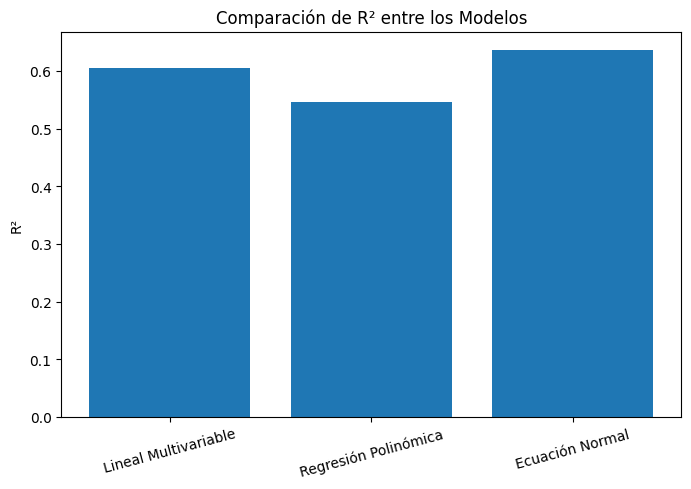

In [45]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['R²']
)

plt.ylabel('R²')
plt.title('Comparación de R² entre los Modelos')
plt.xticks(rotation=15)

plt.show()

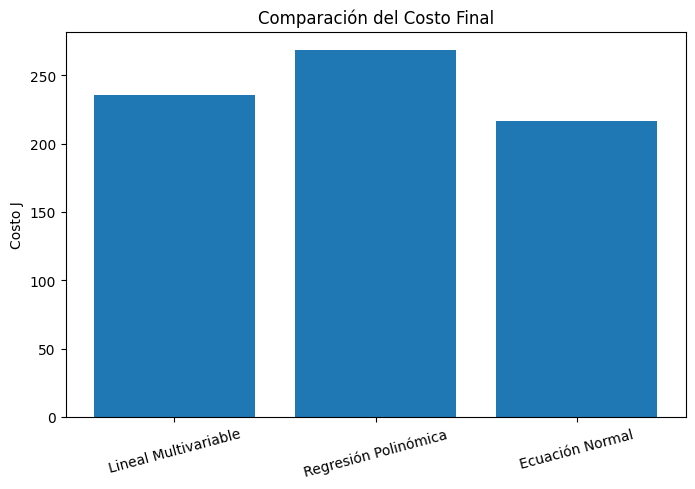

In [46]:
plt.figure(figsize=(8, 5))

plt.bar(
    resultados['Modelo'],
    resultados['Costo']
)

plt.ylabel('Costo J')
plt.title('Comparación del Costo Final')
plt.xticks(rotation=15)

plt.show()

### Interpretación de los Resultados

Al comparar los tres modelos, la Ecuación Normal obtuvo el mejor desempeño, presentando el valor de R² más alto y los menores valores de MAE y RMSE.

La Regresión Lineal Multivariable también obtuvo resultados aceptables, aunque ligeramente inferiores a los obtenidos mediante la Ecuación Normal.

Por otra parte, la Regresión Polinómica presentó un rendimiento menor para las características seleccionadas. Esto demuestra que agregar términos polinómicos no garantiza necesariamente una mejora en la predicción, ya que su efectividad depende de la relación existente entre las variables y la etiqueta `critical_temp`.

En conclusión, para este dataset el modelo que mejor representa los datos es el obtenido mediante la Ecuación Normal.